Learned Hypothesis (Clean): (np.float64(14057.299356000593), np.float64(23366.475107128324), np.float64(114.1053170769504), np.float64(166.65710848858345))


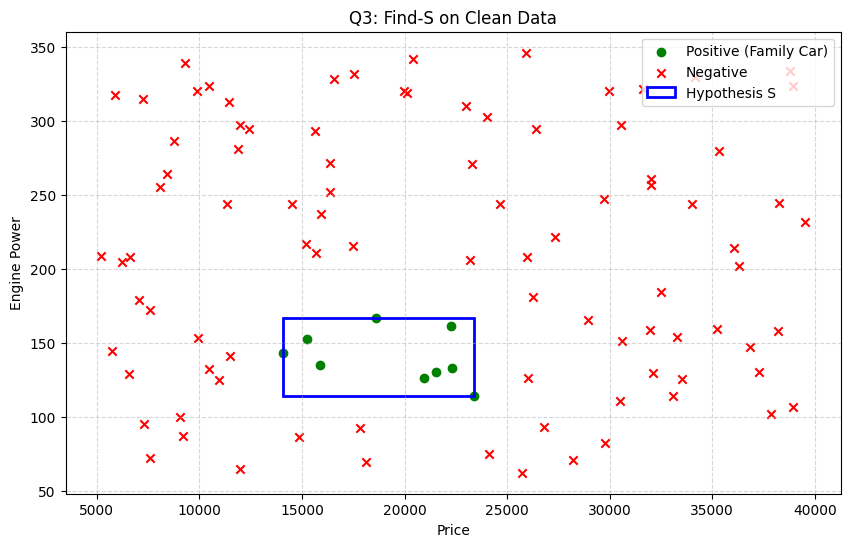

Q4 Accuracy (Clean Model): 96.0%
Learned Hypothesis (Noisy): (np.float64(14057.299356000593), np.float64(38000.0), np.float64(114.1053170769504), np.float64(320.0))


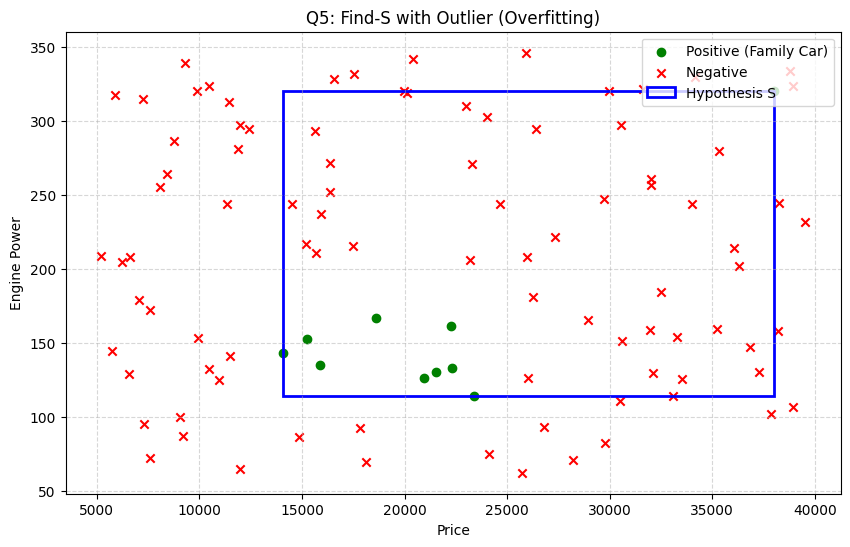

Q5 Accuracy (Noisy Model): 57.99999999999999%


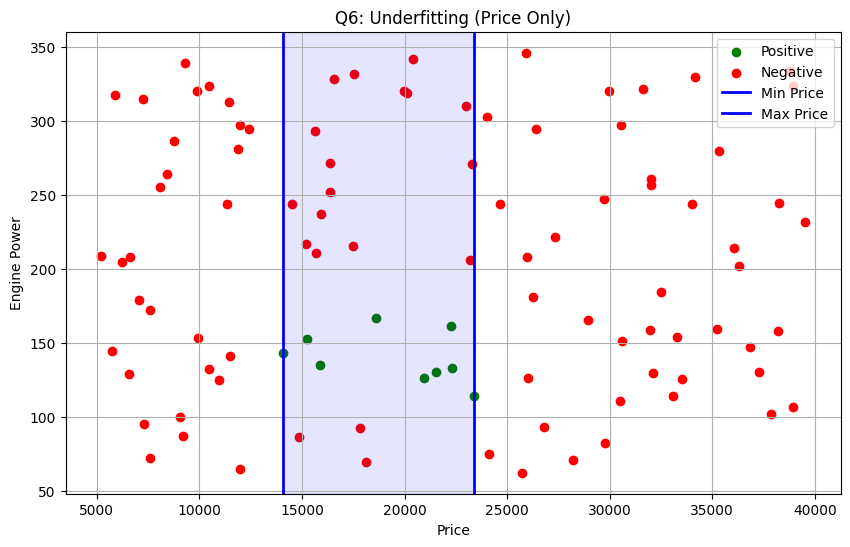

Q6 Accuracy (Restricted Model): 80.0%


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


# 1. Define the "Ground Truth" (The Oracle)

def target_function(price, power):
    """
    Returns 1 (Positive) if the car is a 'Family Car', 0 otherwise.
    Hidden Rule: 12,000 <= Price <= 25,000 AND 110 <= Power <= 190
    """
    if (12000 <= price <= 25000) and (110 <= power <= 190):
        return 1
    return 0


# 2. Data Generation (Training Set)

def generate_data(n_samples=100, seed=42):
    np.random.seed(seed)

    prices = np.random.uniform(5000, 40000, n_samples)
    powers = np.random.uniform(60, 350, n_samples)

    data = []
    for p, hp in zip(prices, powers):
        label = target_function(p, hp)
        data.append([p, hp, label])

    return np.array(data)

# Generate N=100 training samples
training_data = generate_data(100)


# 3. Model Training: The Find-S Algorithm

def train_find_s(data):
    """
    Learns the most specific hypothesis (rectangle) covering all positive examples.
    Returns: (p_min, p_max, e_min, e_max)
    """

    p_min = float('inf')
    p_max = float('-inf')
    e_min = float('inf')
    e_max = float('-inf')

    for sample in data:
        price, power, label = sample


        if label == 1:
            if price < p_min: p_min = price
            if price > p_max: p_max = price
            if power < e_min: e_min = power
            if power > e_max: e_max = power

    return (p_min, p_max, e_min, e_max)

# Train the model
hypothesis = train_find_s(training_data)
print(f"Learned Hypothesis (Clean): {hypothesis}")

#  Visualization Function
def plot_data_and_hypothesis(data, hypothesis, title="Find-S Visualization"):
    plt.figure(figsize=(10, 6))

    # Separate positive and negative examples
    positives = data[data[:, 2] == 1]
    negatives = data[data[:, 2] == 0]

    # Plot points
    plt.scatter(positives[:, 0], positives[:, 1], color='green', label='Positive (Family Car)', marker='o')
    plt.scatter(negatives[:, 0], negatives[:, 1], color='red', label='Negative', marker='x')

    # Draw the learned rectangle
    if hypothesis:
        p_min, p_max, e_min, e_max = hypothesis

        if p_min != float('inf'):
            width = p_max - p_min
            height = e_max - e_min
            rect = patches.Rectangle((p_min, e_min), width, height,
                                     linewidth=2, edgecolor='blue', facecolor='none', label='Hypothesis S')
            plt.gca().add_patch(rect)

    plt.title(title)
    plt.xlabel('Price')
    plt.ylabel('Engine Power')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Visualize Q3 Results
plot_data_and_hypothesis(training_data, hypothesis, title="Q3: Find-S on Clean Data")


# 4. Testing and Generalization

def predict(sample, hypothesis):
    p_min, p_max, e_min, e_max = hypothesis
    price, power = sample[0], sample[1]

    if (p_min <= price <= p_max) and (e_min <= power <= e_max):
        return 1
    return 0

# Generate M=100 new test samples (different seed)
test_data = generate_data(100, seed=99)

# Calculate Accuracy
correct_predictions = 0
for sample in test_data:
    true_label = sample[2]
    predicted_label = predict(sample, hypothesis)
    if predicted_label == true_label:
        correct_predictions += 1

accuracy = (correct_predictions / len(test_data)) * 100
print(f"Q4 Accuracy (Clean Model): {accuracy}%")


# 5. Experiment: Sensitivity to Label Noise


outlier = np.array([[38000, 320, 1]])
noisy_data = np.vstack([training_data, outlier])

# Re-train
noisy_hypothesis = train_find_s(noisy_data)
print(f"Learned Hypothesis (Noisy): {noisy_hypothesis}")

# Visualize Noisy Model
plot_data_and_hypothesis(noisy_data, noisy_hypothesis, title="Q5: Find-S with Outlier (Overfitting)")

# Test Noisy Model on original Test Set
noisy_correct = 0
for sample in test_data:
    if predict(sample, noisy_hypothesis) == sample[2]:
        noisy_correct += 1
noisy_accuracy = (noisy_correct / len(test_data)) * 100
print(f"Q5 Accuracy (Noisy Model): {noisy_accuracy}%")


# 6. Experiment: Underfitting (Price Only)

def train_price_only(data):
    """ Learns a valid range for Price only, ignoring Power. """
    p_min = float('inf')
    p_max = float('-inf')

    for sample in data:
        price, _, label = sample
        if label == 1:
            if price < p_min: p_min = price
            if price > p_max: p_max = price
    return (p_min, p_max)

# Train Restricted Model on CLEAN training data
price_hypothesis = train_price_only(training_data)

# Visualize Restricted Model
plt.figure(figsize=(10, 6))
positives = training_data[training_data[:, 2] == 1]
negatives = training_data[training_data[:, 2] == 0]
plt.scatter(positives[:, 0], positives[:, 1], color='green', label='Positive')
plt.scatter(negatives[:, 0], negatives[:, 1], color='red', label='Negative')

# Draw vertical lines (Infinite Strip)
p_min, p_max = price_hypothesis
plt.axvline(x=p_min, color='blue', linestyle='-', linewidth=2, label='Min Price')
plt.axvline(x=p_max, color='blue', linestyle='-', linewidth=2, label='Max Price')
plt.axvspan(p_min, p_max, color='blue', alpha=0.1)

plt.title("Q6: Underfitting (Price Only)")
plt.xlabel('Price')
plt.ylabel('Engine Power')
plt.legend()
plt.grid(True)
plt.show()

# Test Restricted Model
restricted_correct = 0
for sample in test_data:
    # Predict 1 if price is in range (ignore power)
    pred = 1 if (price_hypothesis[0] <= sample[0] <= price_hypothesis[1]) else 0
    if pred == sample[2]:
        restricted_correct += 1

restricted_accuracy = (restricted_correct / len(test_data)) * 100
print(f"Q6 Accuracy (Restricted Model): {restricted_accuracy}%")
